In [122]:
import pandas as pd
data = pd.read_csv(r"C:\Users\DELL\Desktop\Hands on machine learning\Practice ML\data\linear regression.csv")

In [123]:
data.head()

,Hours Studied (X),Exam Score (Y)
0,1,2
1,2,4
2,3,6
3,4,8
4,5,10


In [124]:
X, y = data["Hours Studied (X)"], data['Exam Score (Y)']

In [125]:
X = X.to_numpy()
y = y.to_numpy()

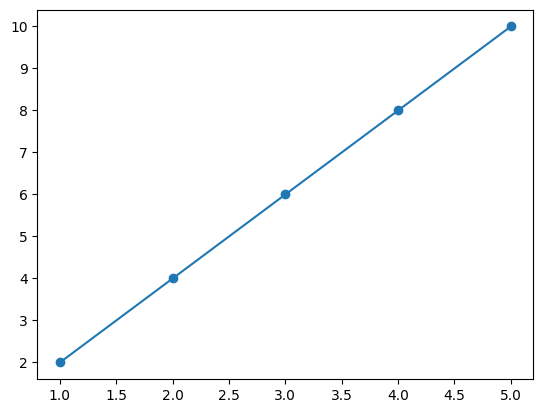

In [126]:
import matplotlib.pyplot as plt
plt.plot(X,y,marker='o', linestyle='-') 

In [127]:
# Initial weights and bias term
import numpy as np
w = 1
b = 0

### Implementing normal equation method

In [128]:
def train_normal(X,y):
    m = X.shape[0]
    ## findingg the best w:
    X_b = np.c_[np.ones((m,1)),X]
    theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    return theta

def predict(X,theta):
    m = X.shape[0]
    X_b = np.c_[np.ones((m,1)), X]  # add bias column
    
    y_pred = X_b.dot(theta)       # predictions
    
    return y_pred

In [129]:
theta=train_normal(X,y)

In [130]:
theta

array([5.66213743e-15, 2.00000000e+00])

In [131]:
predict(X,theta)

array([ 2.,  4.,  6.,  8., 10.])

### Implementing Gradient Descent

Batch Gradient Descent

In [150]:
def train_batch_grad(X,y):
    X = X.reshape(-1,1)
    y = y.reshape(-1,1)    
    
    m,n = X.shape
    X_b = np.c_[np.ones((m,1)),X]
    n_iterations = 1000
    learning_rate = 0.01
    theta_ = np.random.randn(X_b.shape[1],1)
    for i in range(n_iterations): 
        gradients = (2/m) * (X_b.T).dot(X_b.dot(theta_) - y)
        theta_ = theta_ - (learning_rate*gradients)
    return theta_


In [151]:
theta

array([5.66213743e-15, 2.00000000e+00])

In [152]:
grad_theta = train_batch_grad(X,y)
grad_theta

array([[0.01423927],
       [1.99605595]])

In [153]:
predict(X,grad_theta)

array([[2.01029522],
       [4.00635117],
       [6.00240712],
       [7.99846307],
       [9.99451902]])

In [154]:
y

array([ 2,  4,  6,  8, 10])

Stochastic gradient descent

In [165]:
import random
t0,t1 = 5,50
def learning_schedule(t):
    return t0 / (t+t1)

def train_SGD(X,y):
    X = X.reshape(-1,1)
    y = y.reshape(-1,1)
    m,n = X.shape
    X_b = np.c_[np.ones((m, 1)), X]
    n_epochs = 50
    theta = np.random.randn(X_b.shape[1],1)
    for epoch in range(n_epochs):
        for i in range(m):
            random_index = np.random.randint(m)
            rand_instance = X_b[random_index:random_index+1]
            y_i = y[random_index:random_index+1]
            gradients = 2 * rand_instance.T.dot(rand_instance.dot(theta) - y_i)
            eta = learning_schedule(epoch * m + i)
            theta = theta - eta * gradients
    return theta

In [166]:
theta_SGD = train_SGD(X,y)
theta_SGD

array([[-0.031023  ],
       [ 2.01027611]])

In [167]:
predict(X,theta_SGD)

array([[ 1.97925311],
       [ 3.98952921],
       [ 5.99980532],
       [ 8.01008143],
       [10.02035754]])

In [168]:
y

array([ 2,  4,  6,  8, 10])